### Valentina Dilanyan
### EDA


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import plot_tree


warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)


In [2]:
# Dataset
usda_foods = pd.read_csv('comprehensive_foods_usda.csv')

In [3]:

print(" DATASET : USDA FOODS")

print(f"\nShape: {usda_foods.shape}")
print(f"\nColumn Names:\n{usda_foods.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(usda_foods.head(3))


 DATASET : USDA FOODS

Shape: (40000, 24)

Column Names:
['fdc_id', 'food_name', 'data_type', 'food_category', 'brand_owner', 'brand_name', 'ingredients', 'serving_size', 'serving_unit', 'household_serving', 'calories', 'carbs_g', 'calcium_mg', 'fat_g', 'protein_g', 'saturated_fat_g', 'vitamin_c_mg', 'fiber_g', 'iron_mg', 'sodium_mg', 'sugar_g', 'cholesterol_mg', 'health_score', 'food_type']

First 3 rows:


,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,69.00,17.60,8.00,0.10,1.50,0.01,54.10,5.30,1.61,20.00,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,23.00,4.80,10.00,0.30,0.40,0.07,1600.00,0.30,0.50,3.00,4.50,0.00,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,32.00,7.69,12.00,0.30,0.40,0.07,1680.00,1.10,0.20,7.00,NaN,0.00,55,Fruits


In [4]:
print(" DATA QUALITY REPORT")


# Function to analyze missing values
def missing_value_analysis(df, dataset_name):
    print(f"\n{'='*60}")
    print(f" {dataset_name}")
    print(f"{'='*60}")
    
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing_Count': missing.values,
        'Missing_Percentage': missing_pct.values
    })
    
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
    
    if len(missing_df) > 0:
        print(f"\n  Columns with missing values:")
        display(missing_df.style.background_gradient(cmap='Reds', subset=['Missing_Percentage']))
        
        completeness = 100 - missing_df['Missing_Percentage'].mean()
        print(f"\n Overall Completeness: {completeness:.2f}%")
    else:
        print("\n No missing values found! 100% complete dataset.")
    
    return missing_df


missing_usda = missing_value_analysis(usda_foods, "USDA FOODS DATASET")

 DATA QUALITY REPORT

 USDA FOODS DATASET

  Columns with missing values:


,Column,Missing_Count,Missing_Percentage
16,vitamin_c_mg,17060,42.650000
5,brand_name,9746,24.365000
9,household_serving,9210,23.025000
4,brand_owner,8617,21.542500
6,ingredients,8344,20.860000
8,serving_unit,8158,20.395000
7,serving_size,8158,20.395000
17,fiber_g,6275,15.687500
21,cholesterol_mg,5842,14.605000
12,calcium_mg,5785,14.462500



 Overall Completeness: 86.26%


In [5]:
usda_clean = usda_foods.copy()

In [6]:

cols_to_drop = ['data_type', 'household_serving', 'brand_name', 'brand_owner']
for col in cols_to_drop:
    usda_clean.drop(col, axis=1, inplace=True)

Keeping only valid units ('g', 'ml').

In [7]:
print(usda_clean['serving_unit'].unique())
usda_clean['serving_unit'] = usda_clean['serving_unit'].str.lower()

usda_clean.loc[usda_clean['serving_unit'].isin(['grm', 'gm']), 'serving_unit'] = 'g'
usda_clean.loc[usda_clean['serving_unit'].isin(['mlt']), 'serving_unit'] = 'ml'


print(usda_clean['serving_unit'].unique())

valid_units = ['g', 'ml']
usda_clean = usda_clean[usda_clean['serving_unit'].isin(valid_units)]

[nan 'GRM' 'g' 'MLT' 'ml' 'IU' 'MG' 'GM' 'MC']
[nan 'g' 'ml' 'iu' 'mg' 'mc']


Cleaning the missing rows of serving size

In [8]:
usda_clean = usda_clean[usda_clean['serving_size'].notna()] # Keeps only rows where serving_size is NOT missing
usda_clean = usda_clean[usda_clean['serving_size'] >= 1] #For a general food dataset, these are usually errors and maybe I should take a bigger number

Standardizing to 100g portion

In [9]:
nutrient_cols = [
    'calories', 'carbs_g', 'fat_g', 'protein_g',
    'saturated_fat_g', 'fiber_g', 'sugar_g'
]
for col in nutrient_cols:
    usda_clean[col] = usda_clean[col] / usda_clean['serving_size'] * 100



In [10]:
micro_cols = ['calcium_mg', 'iron_mg', 'sodium_mg', 'vitamin_c_mg', 'cholesterol_mg']
for col in micro_cols:
    new_name = col.replace('_mg', '_g')
    usda_clean[new_name] = usda_clean[col] / 1000

# print(micro_cols)

usda_clean.drop(columns=micro_cols, inplace=True)

micro_cols = ['calcium_g', 'iron_g', 'sodium_g', 'vitamin_c_g', 'cholesterol_g']
for col in micro_cols:
    usda_clean[col] = usda_clean[col] / usda_clean['serving_size'] * 100

Physically there can not be more than 100g nutrients in 100g food, so we  have to get rid of them

In [11]:
for col in ['carbs_g', 'fat_g', 'protein_g', 'sugar_g', 'fiber_g', 'saturated_fat_g']:
    usda_clean = usda_clean[usda_clean[col] <= 100]

In [12]:
display(usda_clean.head(3))

,fdc_id,food_name,food_category,ingredients,serving_size,serving_unit,calories,carbs_g,fat_g,protein_g,saturated_fat_g,fiber_g,sugar_g,health_score,food_type,calcium_g,iron_g,sodium_g,vitamin_c_g,cholesterol_g
8158,2742400,AdvancePierre Flamebroiled Rib Shaped Pork Pa...,Meat/Poultry/Other Animals - Prepared/Processed,"Ground Pork (No More Than 20% Fat), Water, Tex...",100.00,g,209.00,10.20,12.10,14.80,4.13,0.99,8.18,60,Meat & Poultry,0.04,0.00,0.29,0.00,0.04
8159,2617100,ALL NATURAL GLUTEN FREE CHICKEN NUGGETS,"Frozen Poultry, Chicken & Turkey","CHICKEN BREAST MEAT, WATER, RICE FLOUR, YELLOW...",85.00,g,228.24,9.69,11.07,22.12,2.76,0.00,0.00,60,Meat & Poultry,0.00,0.00,0.47,0.00,0.06
8162,2607109,AUTHENTIC BARREL RIPENED FETA CHEESE,Cheese,"PASTEURIZED SHEEP AND GOAT'S MILK, SEA SALT, C...",28.00,g,1021.43,0.00,89.29,51.07,63.93,0.00,0.00,40,Dairy,0.76,0.00,4.32,NaN,0.29


###  Data quality and missing values analysis

Define columns to fix

In [13]:
cols_to_fix = micro_cols + nutrient_cols

cols_to_fix.remove('calories')
stats = usda_clean[cols_to_fix].describe()
print(stats)

       calcium_g   iron_g  sodium_g  vitamin_c_g  cholesterol_g  carbs_g  \
count   13731.00 13710.00  13975.00      8224.00       13884.00 14000.00   
mean        0.12     0.00     18.23         0.02           0.07    20.05   
std         0.93     0.04    711.34         0.42           2.31    26.17   
min         0.00     0.00      0.00         0.00           0.00     0.00   
25%         0.00     0.00      0.02         0.00           0.00     2.39   
50%         0.03     0.00      0.18         0.00           0.00     8.14   
75%         0.07     0.00      0.53         0.00           0.04    25.50   
max        70.00     2.89  81714.29        24.00         235.29   100.00   

         fat_g  protein_g  saturated_fat_g  fiber_g  sugar_g  
count 14000.00   14000.00         14000.00 14000.00 14000.00  
mean     10.72       9.35             3.72     1.92     7.66  
std      18.74      13.66             8.10     4.68    14.14  
min       0.00       0.00             0.00     0.00     0.00  


From the results we see some anomalies in calcium, sodium, cholestol etc.

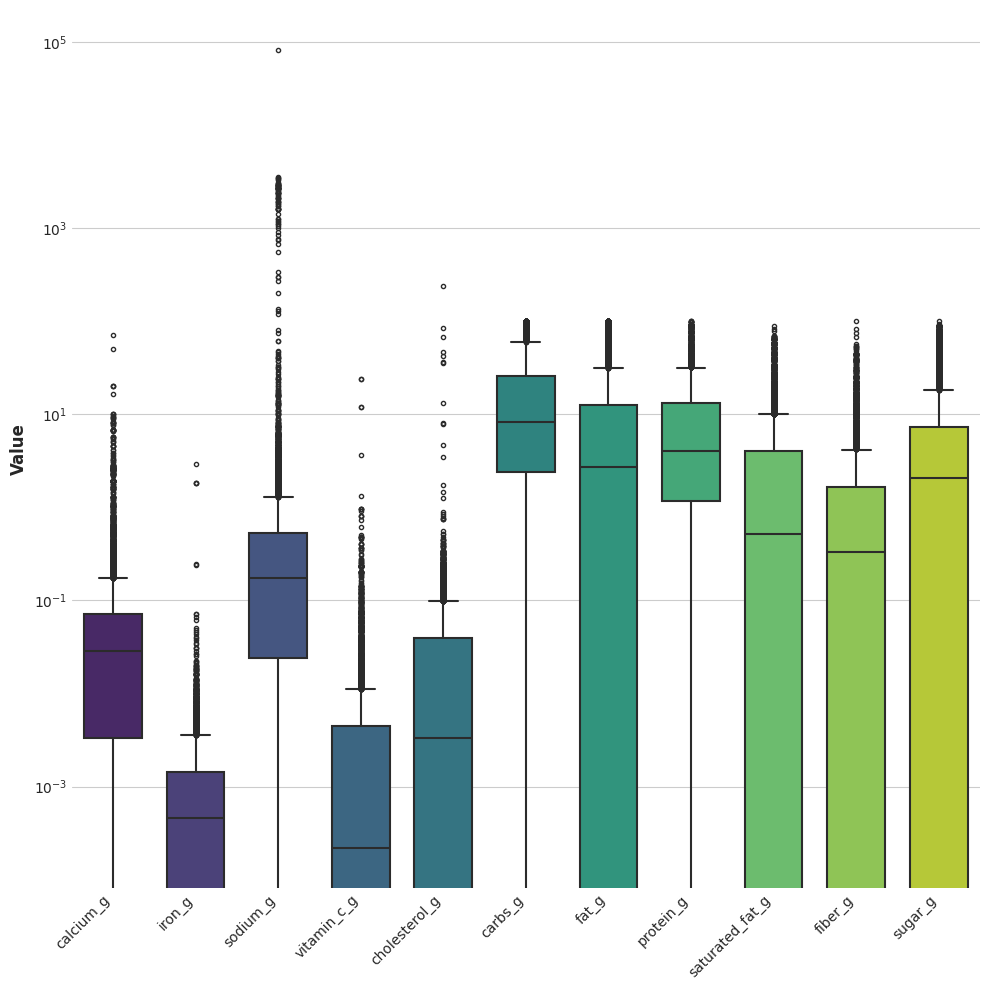

In [14]:

sns.set_style("whitegrid")

plt.figure(figsize=(10, 10))

palette = sns.color_palette("viridis", n_colors=len(cols_to_fix))

ax = sns.boxplot(
    data=usda_clean[cols_to_fix],
    palette=palette,      
    showfliers=True,      
    width=0.7,
    linewidth=1.5,
    fliersize=3           
)


ax.set_yscale('log')


ax.set_ylabel('Value', fontsize=12, fontweight='bold')
# plt.title('Nutrient Distribution Before Cleaning', fontsize=15, pad=20, loc='left')


plt.xticks(rotation=45, ha='right')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [15]:

palette = sns.color_palette("viridis", n_colors=len(cols_to_fix)).as_hex()
color_map = dict(zip(cols_to_fix, palette))

# the summary dataframe 
summary_df = usda_clean[cols_to_fix].describe().T


def color_nutrient_names(index):
   
    return [f'background-color: {color_map.get(name, "white")}; color: white; font-weight: bold' 
            for name in index]


styled_sheet = summary_df.style.apply_index(color_nutrient_names, axis=0) \
    .format("{:.2f}") \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid #dee2e6',
        'padding': '10px'
    })

styled_sheet

,count,mean,std,min,25%,50%,75%,max
calcium_g,13731.00,0.12,0.93,0.00,0.00,0.03,0.07,70.00
iron_g,13710.00,0.00,0.04,0.00,0.00,0.00,0.00,2.89
sodium_g,13975.00,18.23,711.34,0.00,0.02,0.18,0.53,81714.29
vitamin_c_g,8224.00,0.02,0.42,0.00,0.00,0.00,0.00,24.00
cholesterol_g,13884.00,0.07,2.31,0.00,0.00,0.00,0.04,235.29
carbs_g,14000.00,20.05,26.17,0.00,2.39,8.14,25.50,100.00
fat_g,14000.00,10.72,18.74,0.00,0.00,2.69,12.50,100.00
protein_g,14000.00,9.35,13.66,0.00,1.17,4.00,13.22,100.00
saturated_fat_g,14000.00,3.72,8.10,0.00,0.00,0.52,3.97,89.29
fiber_g,14000.00,1.92,4.68,0.00,0.00,0.33,1.67,100.00


In [16]:
# Sorted sodium to see the absolute highest values
high_sodium_check = usda_clean[['food_name', 'sodium_g', 'health_score']].sort_values(by='sodium_g', ascending=False)

print(high_sodium_check.head(20))

                                             food_name  sodium_g  health_score
20624                            ALL PURPOSE SEASONING  81714.29            40
18137  ADOBO ALL PURPOSE SEASONING WITH PEPPER, PEPPER   3500.00            40
10693                 100% NATURAL HIMALAYAN PINK SALT   3472.73            40
18203                      ADOBO WITH CUMIN CON COMINO   3400.00            40
20100             ALL NATURAL HIMALAYAN FINE PINK SALT   3333.33            40
17767                         ABODO WITH CHIPOTLE, HOT   3250.00            40
34493                           BADIA, MEAT TENDERIZER   3054.55            40
34468                     BADIA MEAT TENDERIZER, 2 LBS   3054.55            40
39670                                     BBQ RUB, BBQ   3000.00            40
20631                            ALL PURPOSE SEASONING   3000.00            40
24374                                    ANNATTO SEEDS   2900.00            40
20393                         ALL NATURAL TURKEY BRI

Created mask for values that are physically impossible (> 40g sodium per 100g food)
I used 40 as a rounded upper bound for pure salt

In [17]:

sodium_upper_bound = 40
impossible_sodium_mask = usda_clean['sodium_g'] > sodium_upper_bound
print(f"Dropping {impossible_sodium_mask.sum()} impossible sodium entries.")

usda_clean = usda_clean[~impossible_sodium_mask]


print(usda_clean[['food_name', 'sodium_g']].sort_values(by='sodium_g', ascending=False).head(10))

Dropping 93 impossible sodium entries.
                                               food_name  sodium_g
38551  BARREL-AGED BOURBON HOT SAUCE, BARREL-AGED BOU...     40.00
20109                              ALL NATURAL HOT SAUCE     40.00
38854                                        BASIL PASTE     40.00
19392                               ALBAHACA BASIL PASTE     37.20
19393                               ALBAHACA BASIL PASTE     37.20
18087                               ADEREZO PARA POLLADA     33.40
19114                                         AJO GARLIC     32.00
19118                            AJO MOLIDO GARLIC PASTE     32.00
22728                  AMBA HALDAR FRESH TURMERIC PICKLE     31.25
29024                            AROY-D, RED CURRY PASTE     30.67


In [18]:
print(usda_clean['food_category'].value_counts())


food_category
Milk                                               844
Fruit & Vegetable Juice, Nectars & Fruit Drinks    817
Cakes, Cupcakes, Snack Cakes                       626
Cheese                                             575
Pre-Packaged Fruit & Vegetables                    537
                                                  ... 
Breakfast Drinks                                     1
Liquid Water Enhancer                                1
Children's Nutritional Supplements                   1
Fish Substitutes                                     1
Vegetables  Unprepared/Unprocessed (Frozen)          1
Name: count, Length: 171, dtype: int64


In [19]:
def remove_group_outliers(df, columns, group_col):
    df_cleaned = df.copy()
    
    for col in columns:
        # Q1 and Q3 for each group
        q1 = df_cleaned.groupby(group_col)[col].transform(lambda x: x.quantile(0.25))
        q3 = df_cleaned.groupby(group_col)[col].transform(lambda x: x.quantile(0.75))
        iqr = q3 - q1
        
        lower_bound = q1 - 3 * iqr
        upper_bound = q3 + 3 * iqr
        
    
        mask = (df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound) | df_cleaned[col].isna()
        df_cleaned = df_cleaned[mask]
        
    return df_cleaned

usda_clean = remove_group_outliers(usda_clean, cols_to_fix, 'food_type')

print(f"Remaining rows after grouped IQR: {len(usda_clean)}")

Remaining rows after grouped IQR: 8899


In [20]:

missing_usda = missing_value_analysis(usda_clean, "USDA FOODS DATASET")


 USDA FOODS DATASET

  Columns with missing values:


,Column,Missing_Count,Missing_Percentage
18,vitamin_c_g,3672,41.263063
16,iron_g,184,2.067648
15,calcium_g,164,1.842904
6,calories,88,0.988875
19,cholesterol_g,79,0.887740
3,ingredients,38,0.427014
2,food_category,33,0.370828
17,sodium_g,19,0.213507



 Overall Completeness: 93.99%


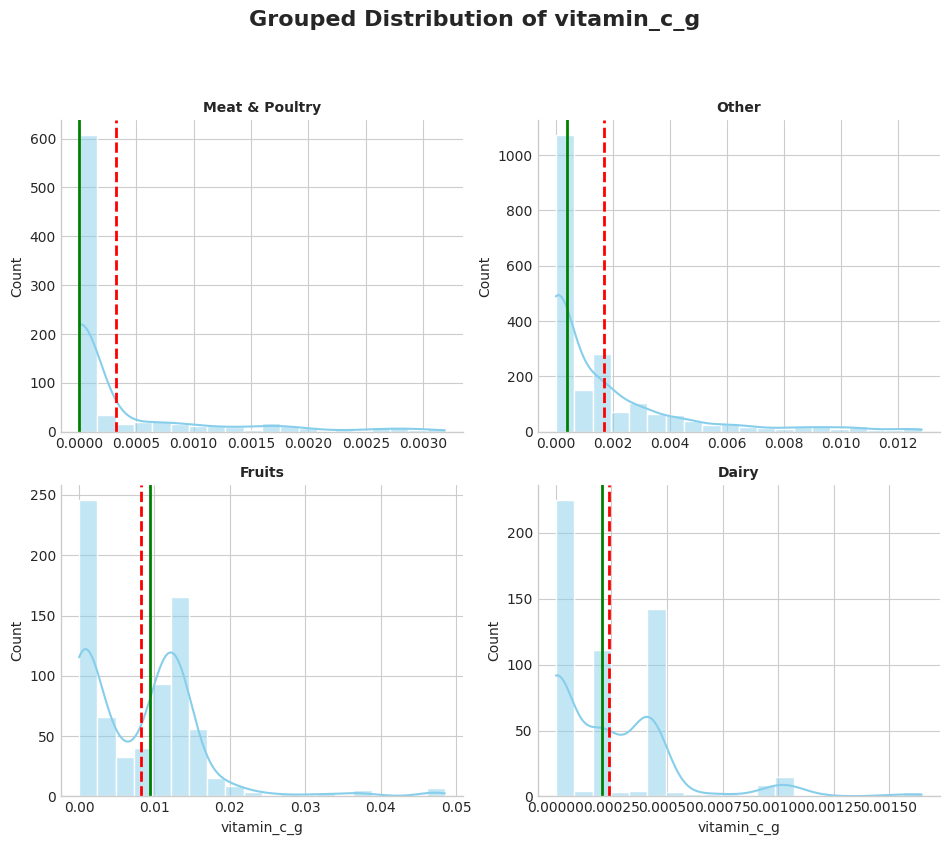

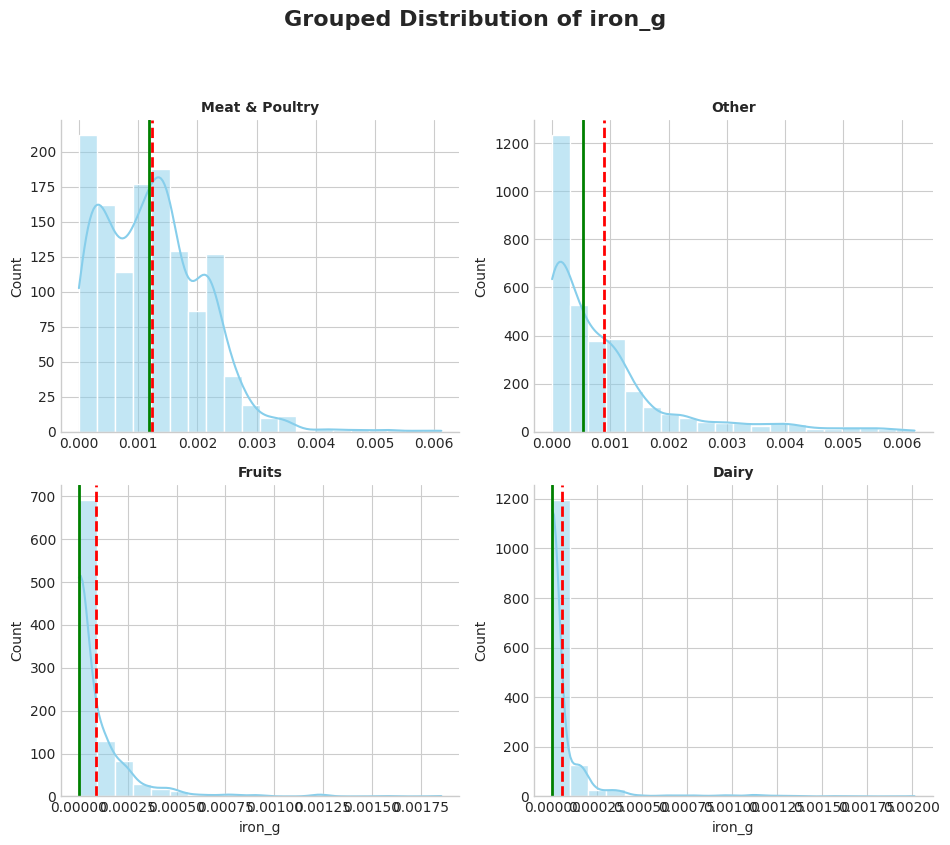

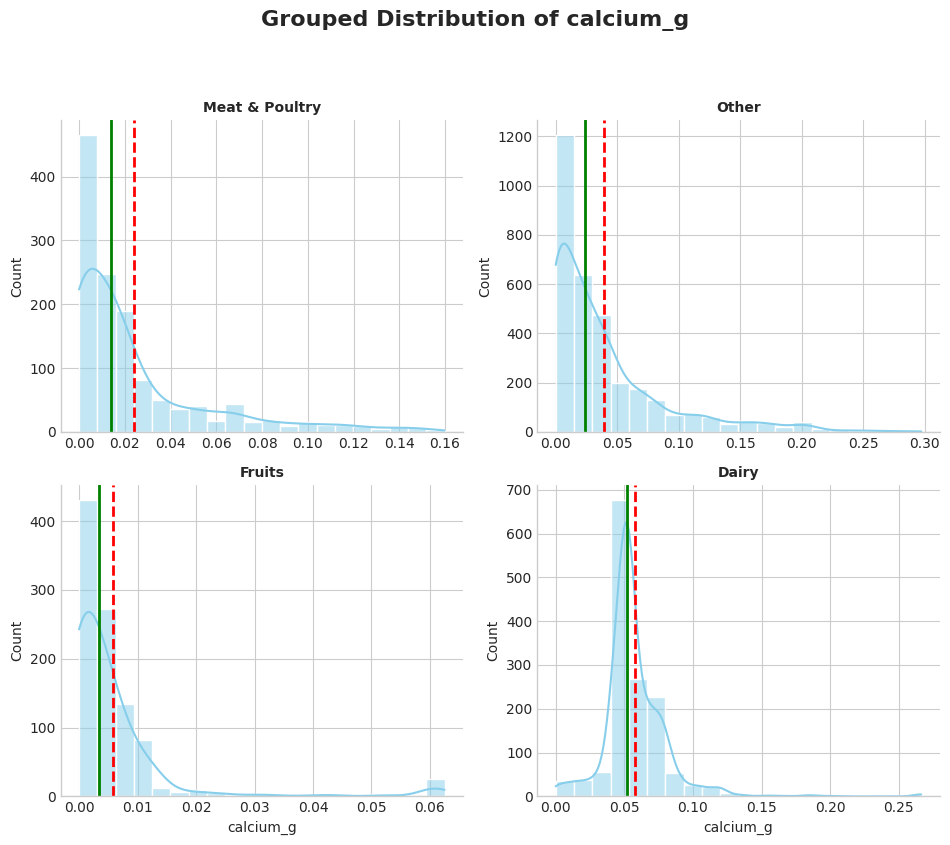

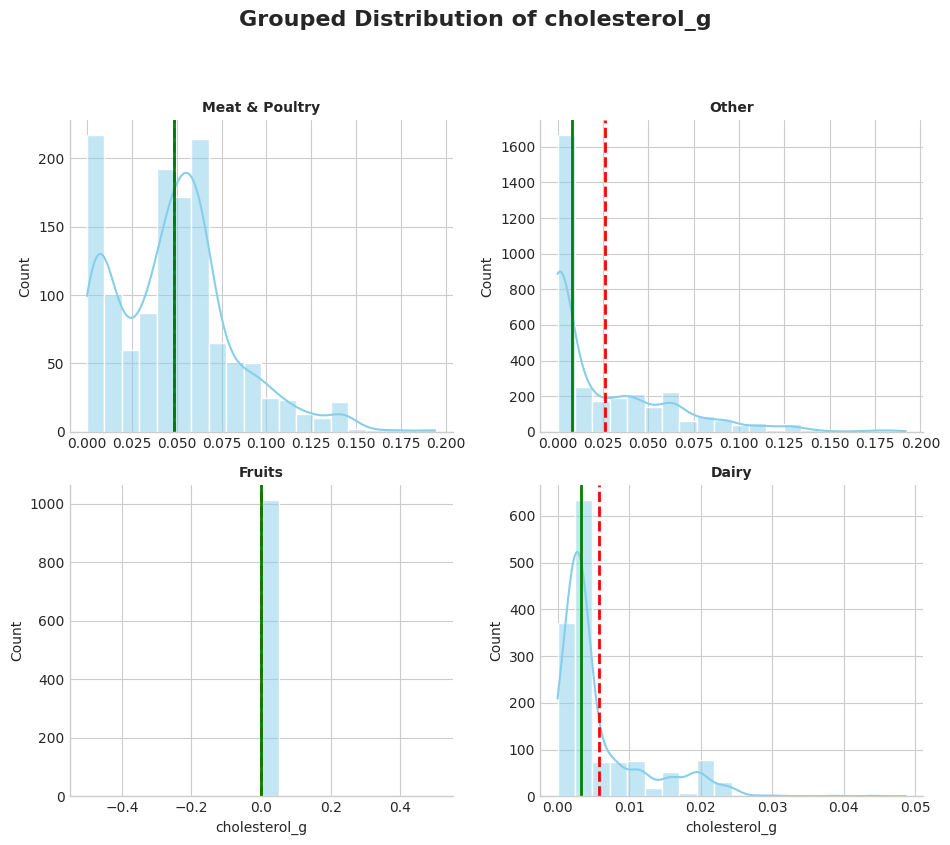

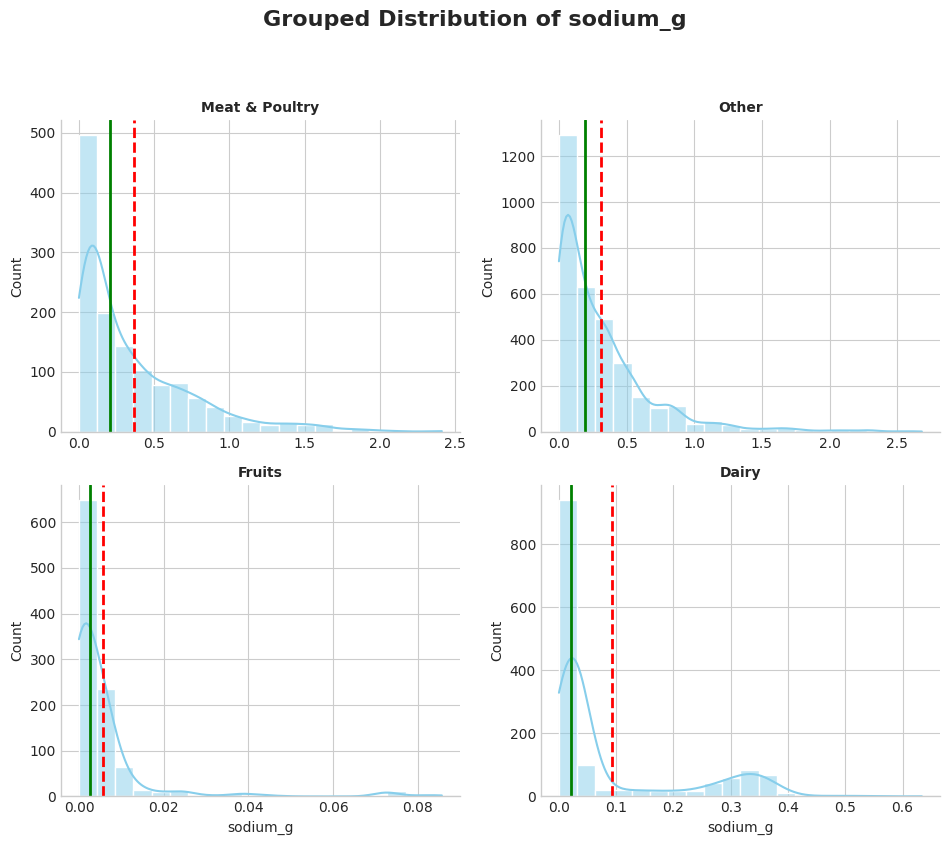

In [21]:
def plot_nutrient_histograms_by_type(df, columns, group_col='food_type', top_n=4):
    top_types = df[group_col].value_counts().nlargest(top_n).index
    df_filtered = df[df[group_col].isin(top_types)]

    for col in columns:
       
        g = sns.FacetGrid(df_filtered, col=group_col, col_wrap=2, height=4, aspect=1.2, sharex=False, sharey=False)
        
        def draw_distribution(x, **kwargs):
           
            kwargs.pop('color', None) 
            
         
            sns.histplot(x, kde=True, color='skyblue', bins=20, **kwargs)
            
            # Calculate local statistics
            mean_val = x.mean()
            median_val = x.median()
            
            plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
            plt.legend(fontsize='small')

        g.map(draw_distribution, col)
        g.set_titles("{col_name}", fontweight='bold')

        g.figure.suptitle(f'Grouped Distribution of {col}', fontsize=16, fontweight='bold', y=1.05)
        
        plt.tight_layout()
        plt.show()

cols_to_check = ['vitamin_c_g', 'iron_g', 'calcium_g', 'cholesterol_g', 'sodium_g']
plot_nutrient_histograms_by_type(usda_clean, cols_to_check)

In [22]:

usda_clean[cols_to_fix] = usda_clean.groupby('food_type')[cols_to_fix].transform(lambda x: x.fillna(x.median()))

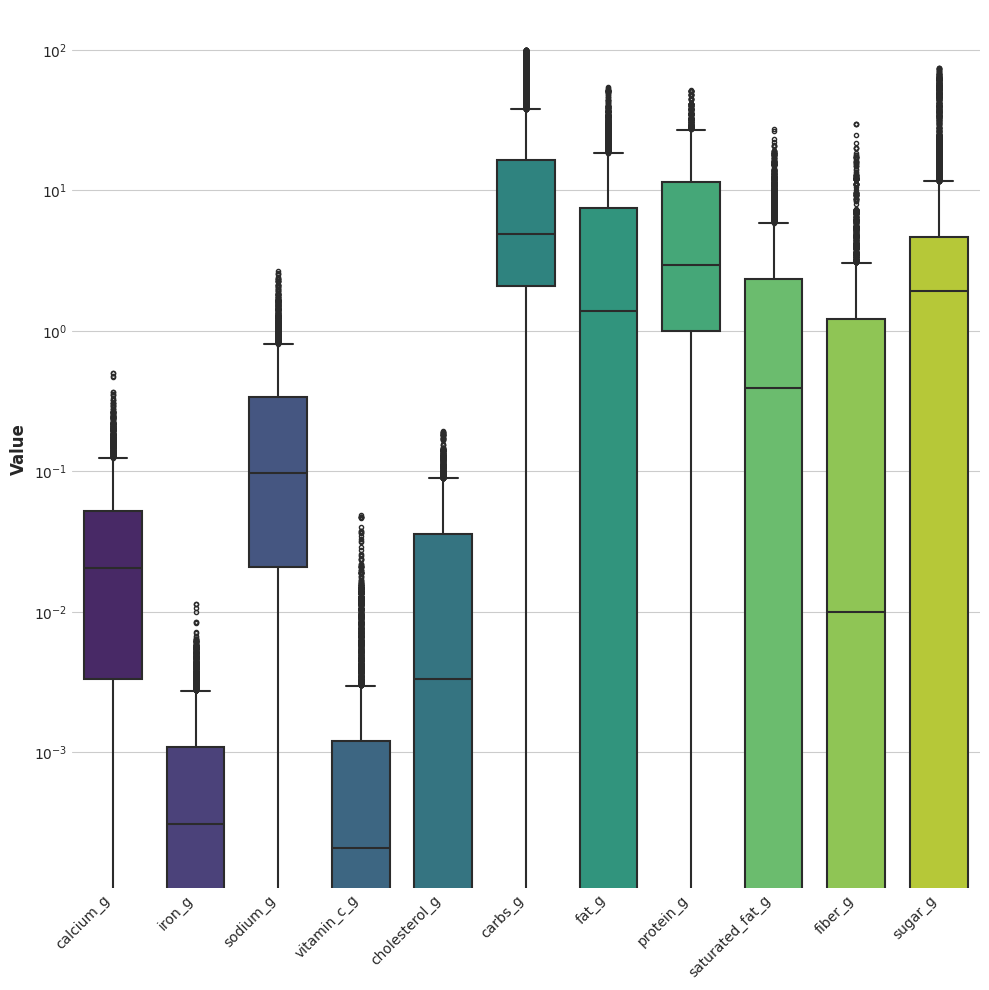

In [23]:



plt.figure(figsize=(10, 10))

ax = sns.boxplot(
    data=usda_clean[cols_to_fix],
    palette=palette,      
    showfliers=True,    
    width=0.7,
    linewidth=1.5,
    fliersize=3       
)


ax.set_yscale('log')


ax.set_ylabel('Value', fontsize=12, fontweight='bold')
# plt.title('Nutrient Distribution After Cleaning', fontsize=15, pad=20, loc='left')

plt.xticks(rotation=45, ha='right')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [24]:

palette = sns.color_palette("viridis", n_colors=len(cols_to_fix)).as_hex()
color_map = dict(zip(cols_to_fix, palette))

summary_df = usda_clean[cols_to_fix].describe().T

def color_nutrient_names(index):
 
    return [f'background-color: {color_map.get(name, "white")}; color: white; font-weight: bold' 
            for name in index]

styled_sheet = summary_df.style.apply_index(color_nutrient_names, axis=0) \
    .format("{:.2f}") \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid #dee2e6',
        'padding': '10px'
    })

styled_sheet

,count,mean,std,min,25%,50%,75%,max
calcium_g,8899.00,0.04,0.04,0.00,0.00,0.02,0.05,0.50
iron_g,8899.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
sodium_g,8899.00,0.23,0.32,0.00,0.02,0.10,0.34,2.68
vitamin_c_g,8899.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05
cholesterol_g,8899.00,0.02,0.03,0.00,0.00,0.00,0.04,0.19
carbs_g,8899.00,13.95,21.17,0.00,2.08,4.91,16.35,100.00
fat_g,8899.00,5.26,7.87,0.00,0.00,1.39,7.43,54.29
protein_g,8899.00,6.82,8.06,0.00,0.99,2.95,11.39,51.48
saturated_fat_g,8899.00,1.83,3.05,0.00,0.00,0.39,2.36,27.25
fiber_g,8899.00,0.91,1.90,0.00,0.00,0.01,1.22,29.76


In [25]:
usda_clean['calories'].describe()

count   8811.00
mean     130.97
std      141.08
min        0.00
25%       25.81
50%       77.88
75%      187.61
max      840.00
Name: calories, dtype: float64

In [26]:
missing_cal_mask = usda_clean['calories'].isna()

#  Atwater formula to calcultae calories: (Protein * 4) + (Carbs * 4) + (Fat * 9)

usda_clean.loc[missing_cal_mask, 'calories'] = (
    (usda_clean.loc[missing_cal_mask, 'protein_g'] * 4) +
    (usda_clean.loc[missing_cal_mask, 'carbs_g'] * 4) +
    (usda_clean.loc[missing_cal_mask, 'fat_g'] * 9)
)

print(f"Standard Deviation: {usda_clean['calories'].std()}")
print(f"Mean Calories: {usda_clean['calories'].mean()}")

print(f"Missing calories: {usda_clean['calories'].isna().sum()}")

Standard Deviation: 140.93760124063672
Mean Calories: 130.82353304687555
Missing calories: 0


In [27]:
usda_clean.isnull().sum()

fdc_id              0
food_name           0
food_category      33
ingredients        38
serving_size        0
serving_unit        0
calories            0
carbs_g             0
fat_g               0
protein_g           0
saturated_fat_g     0
fiber_g             0
sugar_g             0
health_score        0
food_type           0
calcium_g           0
iron_g              0
sodium_g            0
vitamin_c_g         0
cholesterol_g       0
dtype: int64

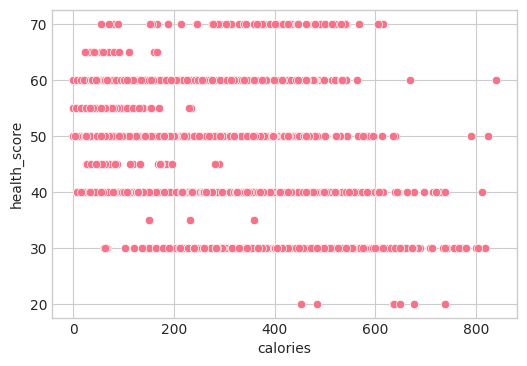

In [28]:

# simple scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=usda_clean['calories'], y=usda_clean['health_score'])
# plt.title("Diagnostics: Calories vs Health Score")
plt.show()

In [29]:
Q1 = usda_clean['calories'].quantile(0.25)
Q3 = usda_clean['calories'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data
usda_clean = usda_clean[(usda_clean['calories'] >= lower_bound) & 
                              (usda_clean['calories'] <= upper_bound)]

print(f"New Max: {usda_clean['calories'].max()}")

New Max: 429.4117647058823


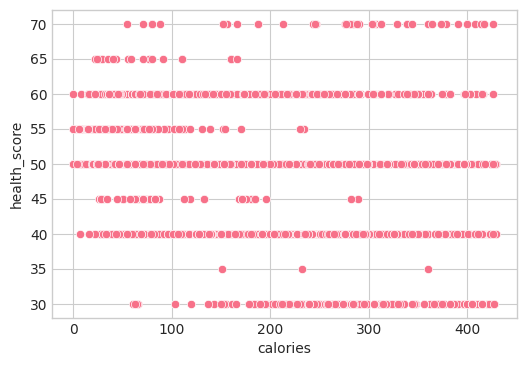

In [30]:
# simple scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=usda_clean['calories'], y=usda_clean['health_score'])
# plt.title("Diagnostics: Calories vs Health Score")
plt.show()

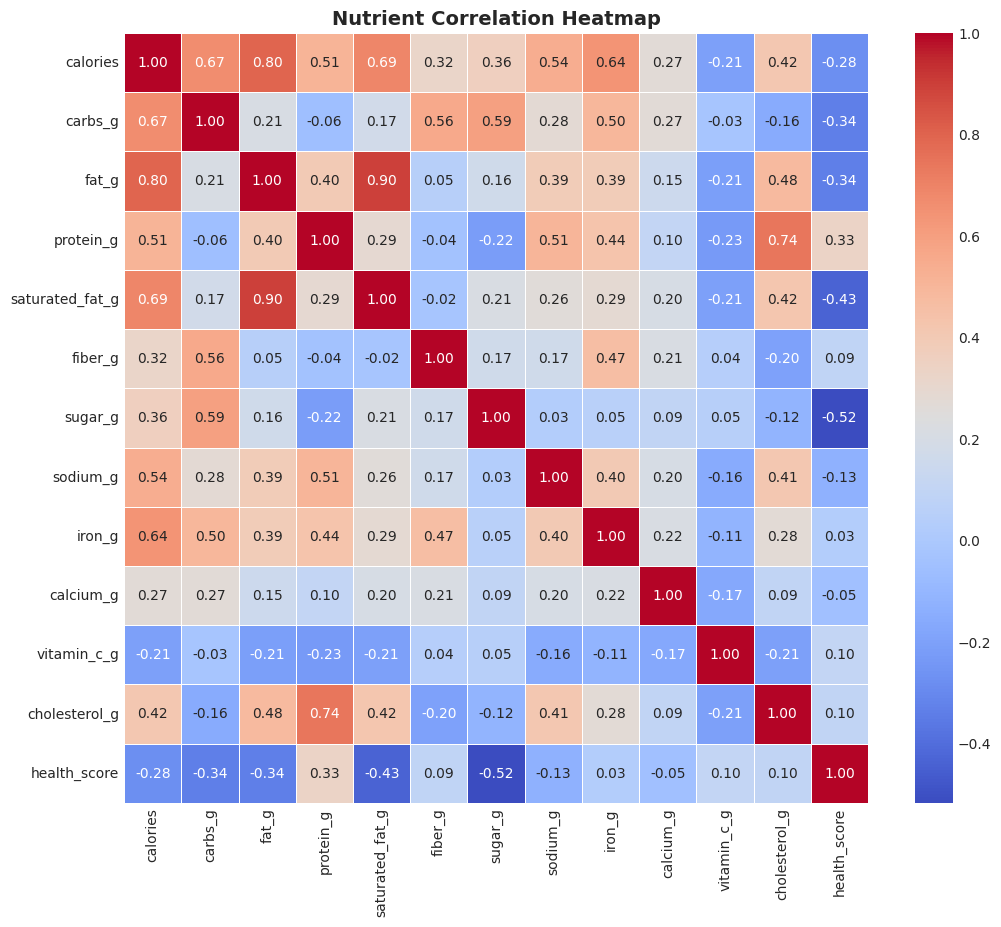

In [31]:
correlation_cols = [
    'calories', 'carbs_g', 'fat_g', 'protein_g', 'saturated_fat_g', 
    'fiber_g', 'sugar_g', 'sodium_g', 'iron_g', 'calcium_g', 'vitamin_c_g',
    'cholesterol_g', 'health_score'
]

corr_matrix = usda_clean[correlation_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Nutrient Correlation Heatmap')
plt.show()

Consider the correlations with health score

Fiber with micro nutrients like vitamin c and iron should have positive correlation


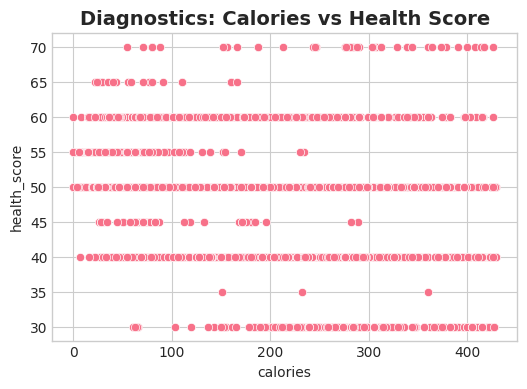

In [32]:

plt.figure(figsize=(6,4))
sns.scatterplot(x=usda_clean['calories'], y=usda_clean['health_score'])
plt.title("Diagnostics: Calories vs Health Score")
plt.show()

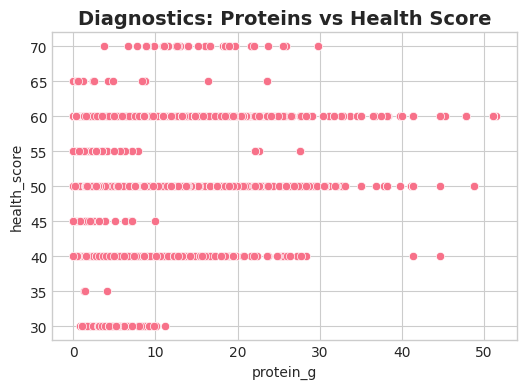

In [33]:

plt.figure(figsize=(6,4))
sns.scatterplot(x=usda_clean['protein_g'], y=usda_clean['health_score'])
plt.title("Diagnostics: Proteins vs Health Score")
plt.show()

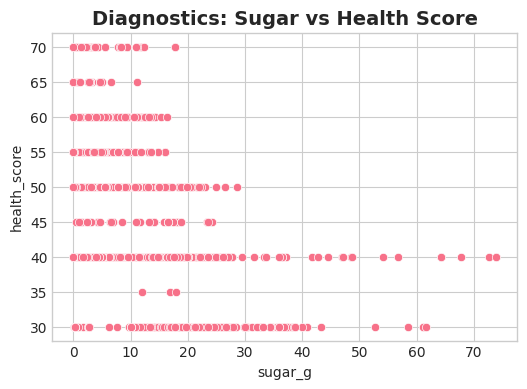

In [34]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=usda_clean['sugar_g'], y=usda_clean['health_score'])
plt.title("Diagnostics: Sugar vs Health Score")
plt.show()

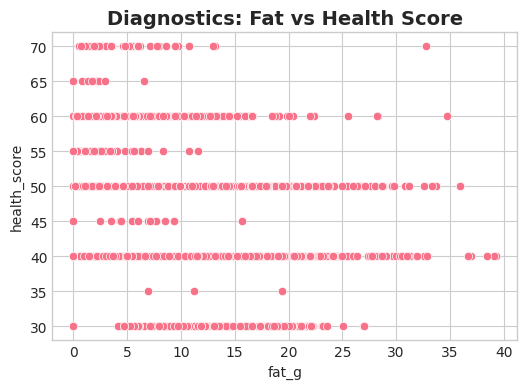

In [35]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=usda_clean['fat_g'], y=usda_clean['health_score'])
plt.title("Diagnostics: Fat vs Health Score")
plt.show()

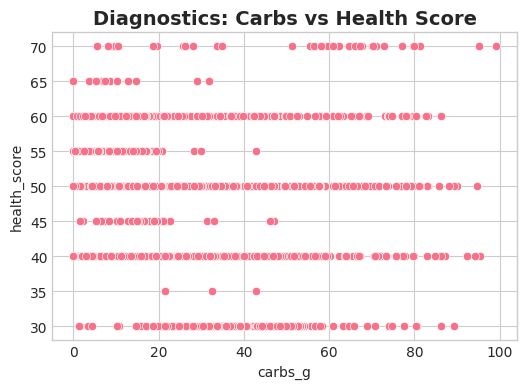

In [36]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=usda_clean['carbs_g'], y=usda_clean['health_score'])
plt.title("Diagnostics: Carbs vs Health Score")
plt.show()

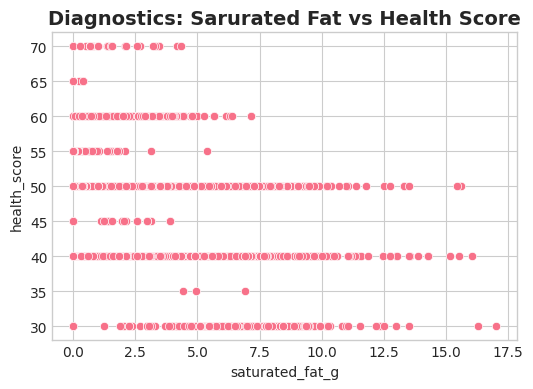

In [37]:

plt.figure(figsize=(6,4))
sns.scatterplot(x=usda_clean['saturated_fat_g'], y=usda_clean['health_score'])
plt.title("Diagnostics: Sarurated Fat vs Health Score")
plt.show()

In [38]:
for item in sorted(usda_clean['food_category'].dropna().unique()):
    print(item)

Alcohol
All Noodles
Bacon, Sausages & Ribs
Baking Additives & Extracts
Baking Decorations & Dessert Toppings
Baking/Cooking Mixes/Supplies
Biscuits/Cookies
Bread
Bread & Muffin Mixes
Breads & Buns
Breakfast Drinks
Breakfast Sandwiches, Biscuits & Meals
Cake, Cookie & Cupcake Mixes
Cakes, Cupcakes, Snack Cakes
Candy
Canned & Bottled Beans
Canned Condensed Soup
Canned Fruit
Canned Meat
Canned Seafood
Canned Soup
Canned Tuna
Canned Vegetables
Cereal
Cheese
Cheese/Cheese Substitutes
Children's Nutritional Supplements
Chili & Stew
Chips, Pretzels & Snacks
Chocolate
Coffee
Cooked & Prepared
Cookies & Biscuits
Crackers & Biscotti
Cream
Croissants, Sweet Rolls, Muffins & Other Pastries
Crusts & Dough
Deli Salads
Dips & Salsa
Dough Based Products / Meals
Eggs & Egg Substitutes
Energy, Protein & Muscle Recovery Drinks
Entrees, Sides & Small Meals
Fish  Unprepared/Unprocessed
Fish & Seafood
Fish - Prepared/Processed
Fish Substitutes
Flavored Rice Dishes
Flours & Corn Meal
French Fries, Potatoes &

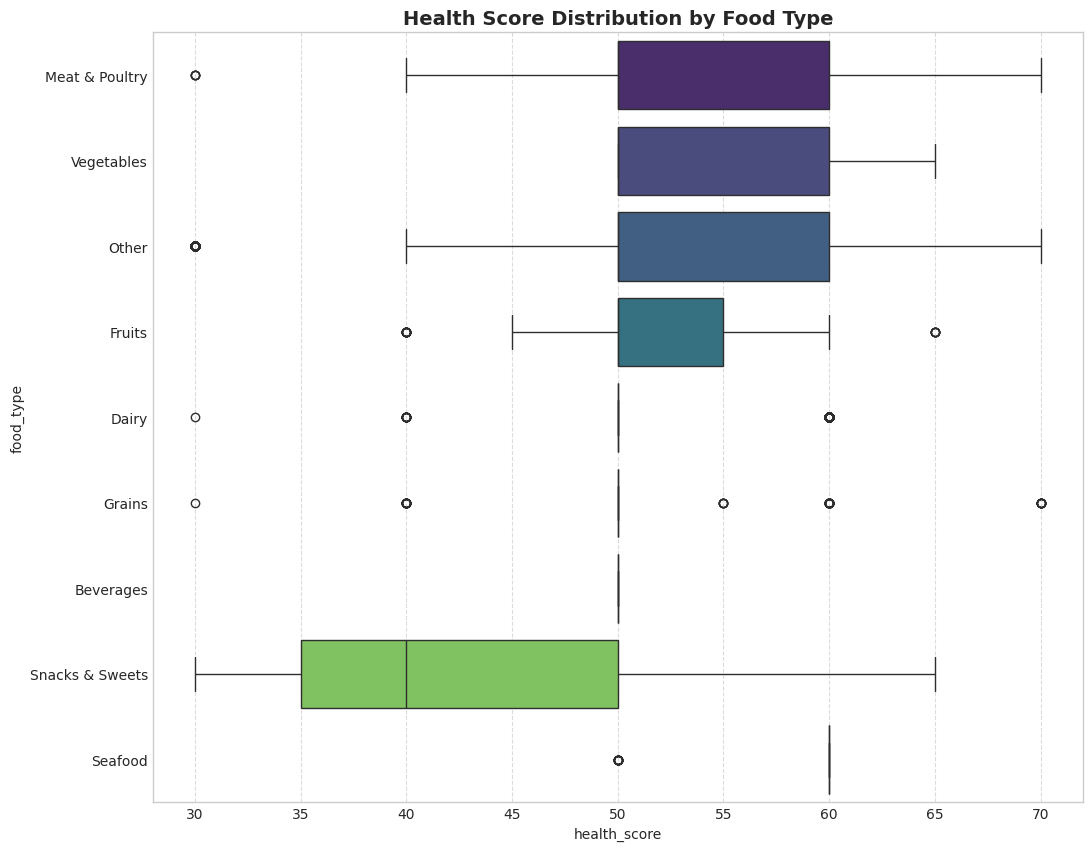

In [39]:
plt.figure(figsize=(12, 10))
sns.boxplot(data=usda_clean, x='health_score', y='food_type', palette='viridis')
plt.title('Health Score Distribution by Food Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


<Figure size 1400x1000 with 0 Axes>

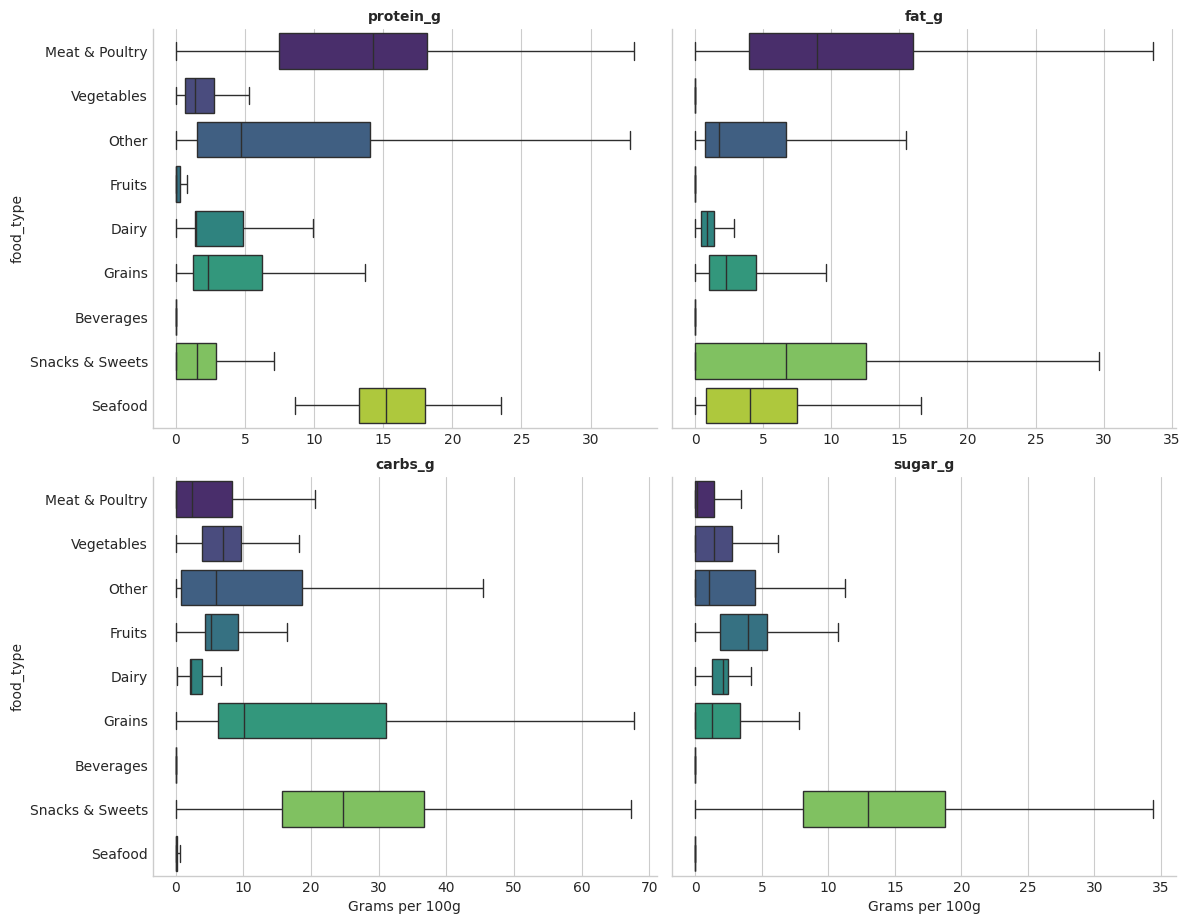

In [40]:
nutrients = ['protein_g', 'fat_g', 'carbs_g', 'sugar_g']

df_melted = usda_clean.melt(
    id_vars=['food_type'], 
    value_vars=nutrients, 
    var_name='Nutrient', 
    value_name='Grams per 100g'
)

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")


g = sns.catplot(
    data=df_melted, 
    x='Grams per 100g', 
    y='food_type', 
    col='Nutrient', 
    kind='box', 
    col_wrap=2,           
    aspect=1.2,
    sharex=False,         
    palette='viridis',
    showfliers=False      
)

g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
# g.fig.suptitle('Nutrient Distribution by Category', fontsize=16)

plt.show()

In [41]:
usda_clean.head()

,fdc_id,food_name,food_category,ingredients,serving_size,serving_unit,calories,carbs_g,fat_g,protein_g,saturated_fat_g,fiber_g,sugar_g,health_score,food_type,calcium_g,iron_g,sodium_g,vitamin_c_g,cholesterol_g
8159,2617100,ALL NATURAL GLUTEN FREE CHICKEN NUGGETS,"Frozen Poultry, Chicken & Turkey","CHICKEN BREAST MEAT, WATER, RICE FLOUR, YELLOW...",85.00,g,228.24,9.69,11.07,22.12,2.76,0.00,0.00,60,Meat & Poultry,0.00,0.00,0.47,0.00,0.06
8165,2611238,BLUE LAKE CUT GREEN BEANS,Canned Vegetables,"GREEN BEANS, WATER, SEA SALT",121.00,g,14.05,2.05,0.00,0.69,0.00,0.66,0.00,50,Vegetables,0.02,0.00,0.26,0.00,0.00
8171,2725305,Ciabatta Pepper Jack Melt WG,Sandwiches/Filled Rolls/Wraps,"Cheese (Cultured Milk, Jalapeno Peppers, Salt,...",111.00,g,267.57,21.89,14.59,12.97,8.12,1.62,0.81,40,Other,0.29,0.00,0.59,0.00,0.04
8172,1909487,"COCONUT WATER BARS, MANGO",Ice Cream & Frozen Yogurt,"COCONUT WATER FROM CONCENTRATE, CANE SUGAR, CO...",89.00,ml,125.84,21.46,3.79,0.00,3.79,1.24,20.22,40,Other,0.00,0.00,0.07,0.00,0.00
8173,2625976,"DEATH WISH COFFEE CO LATTE, 8 FL OZ",Other Drinks,"ORGANIC REDUCED FAT MILK, ORGANIC BREWED COFFE...",240.00,ml,29.58,5.38,0.52,1.04,0.43,0.00,3.46,50,Other,0.04,0.00,0.05,0.00,0.00


In [42]:
def health_class(score):
    if score < 40:
        return "Unhealthy"
    elif score < 60:
        return "Moderate"
    else:
        return "Healthy"

usda_clean['health_class'] = usda_clean['health_score'].apply(health_class)

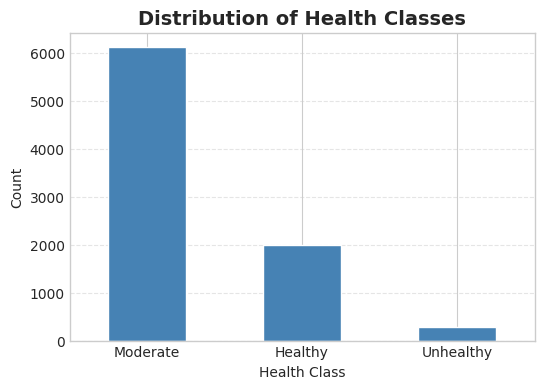

In [43]:
plt.figure(figsize=(6,4))
counts  = usda_clean['health_class'].value_counts()
counts.plot(kind='bar', color='steelblue')

plt.xlabel("Health Class")
plt.ylabel("Count")
plt.title("Distribution of Health Classes")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [44]:
features = [
    'protein_g',
    'saturated_fat_g',
    'carbs_g',
    'sugar_g',
    'fiber_g',
    'sodium_g'
]

In [45]:
X = usda_clean[features]
y = usda_clean['health_class']

In [46]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE on training data
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)


In [47]:
pd.Series(y_train_resampled).value_counts()

health_class
Healthy      4888
Unhealthy    4888
Moderate     4888
Name: count, dtype: int64

In [48]:
train_scores = []
test_scores = []

k_values = range(1, 10)

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_resampled, y_train_resampled)

    train_scores.append(
        model.score(X_train_resampled, y_train_resampled)
    )

    test_scores.append(
        model.score(X_test_scaled, y_test)
    )

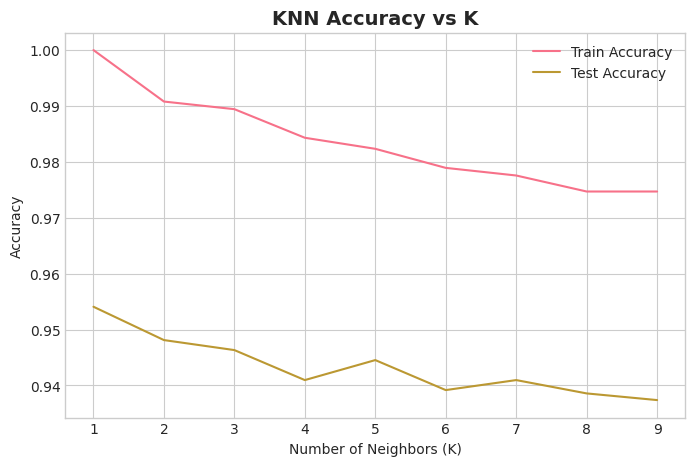

In [49]:
plt.figure(figsize=(8,5))

plt.plot(k_values, train_scores, label='Train Accuracy')
plt.plot(k_values, test_scores, label='Test Accuracy')

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K')

plt.legend()

plt.show()

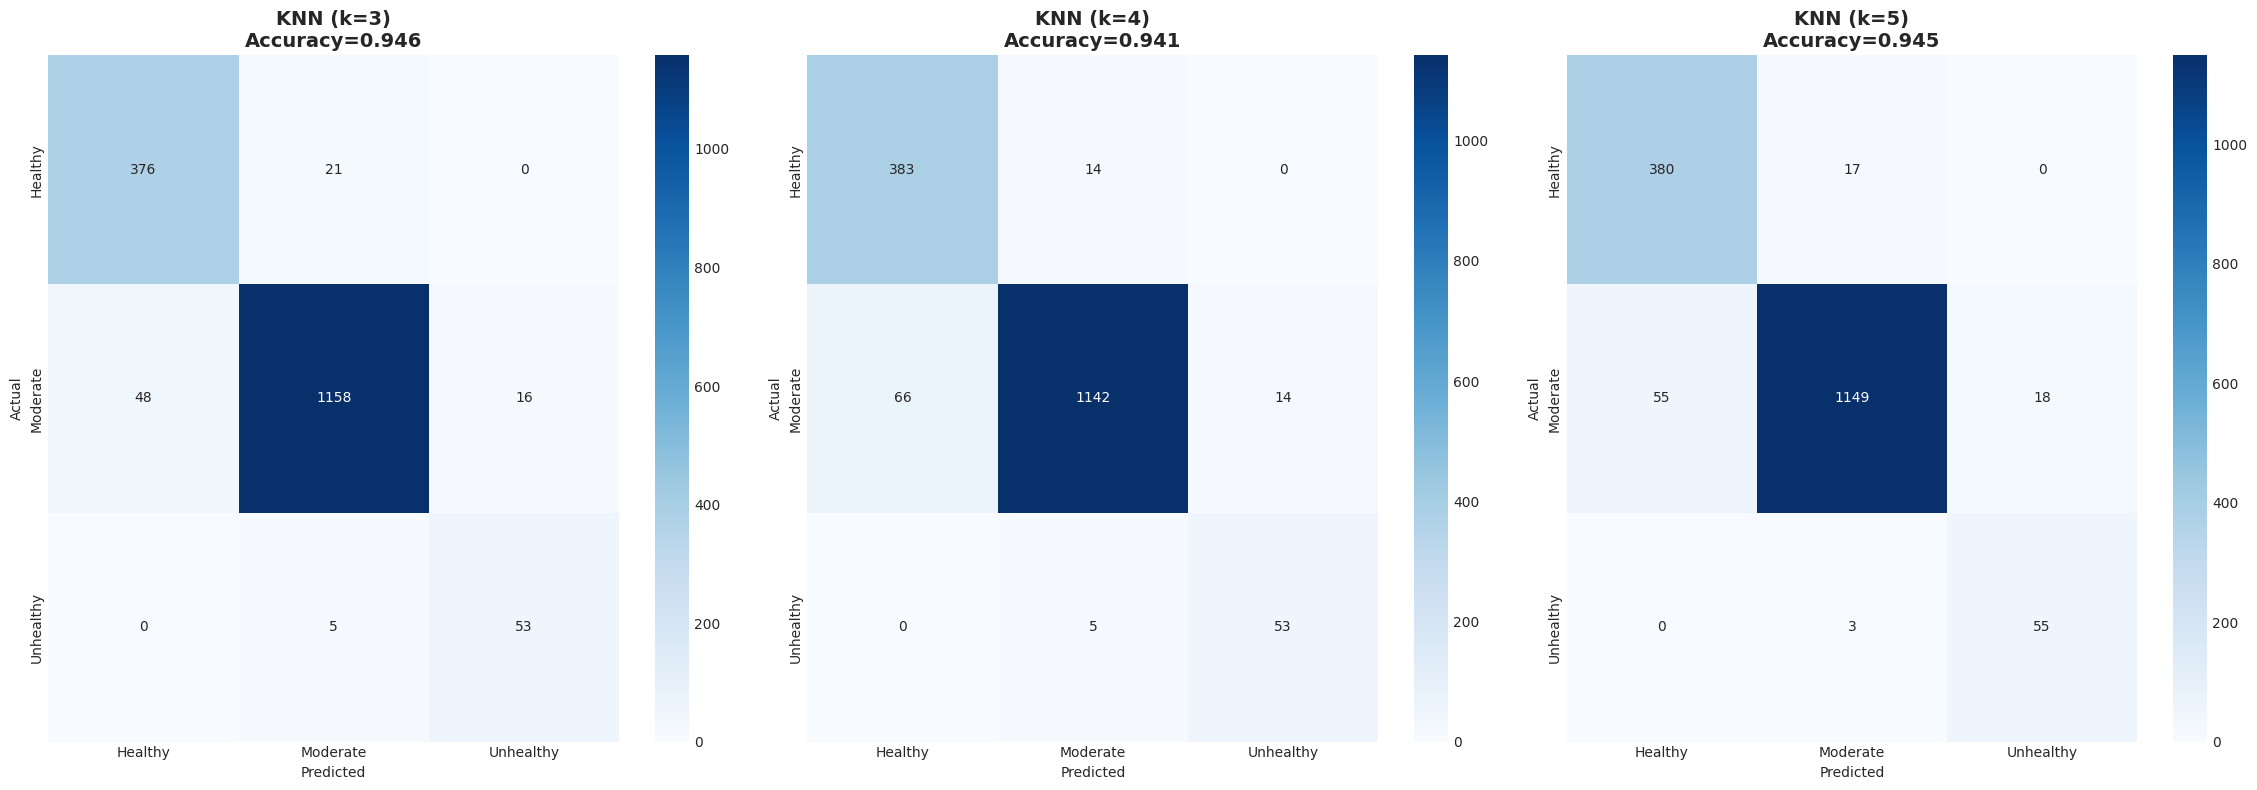

,precision,recall,f1-score,support,k
Healthy,0.89,0.95,0.92,397.00,3
Moderate,0.98,0.95,0.96,1222.00,3
Unhealthy,0.77,0.91,0.83,58.00,3
accuracy,0.95,0.95,0.95,0.95,3
macro avg,0.88,0.94,0.90,1677.00,3
weighted avg,0.95,0.95,0.95,1677.00,3
Healthy,0.85,0.96,0.91,397.00,4
Moderate,0.98,0.93,0.96,1222.00,4
Unhealthy,0.79,0.91,0.85,58.00,4
accuracy,0.94,0.94,0.94,0.94,4


In [50]:
best_ks = [3, 4, 5]
accuracies = []
reports = []

fig, axes = plt.subplots(1, len(best_ks), figsize=(23, 8))

for i, k in enumerate(best_ks):

    
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_resampled, y_train_resampled)

    
    y_pred = knn.predict(X_test_scaled)
    
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
    df = pd.DataFrame(report).transpose()

    df['k'] = k

    reports.append(df)


    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=knn.classes_,
        yticklabels=knn.classes_,
        ax=axes[i]
    )

    axes[i].set_title(f'KNN (k={k})\nAccuracy={acc:.3f}')
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

final_report = pd.concat(reports)
acc_knn = max(accuracies)

display(final_report)

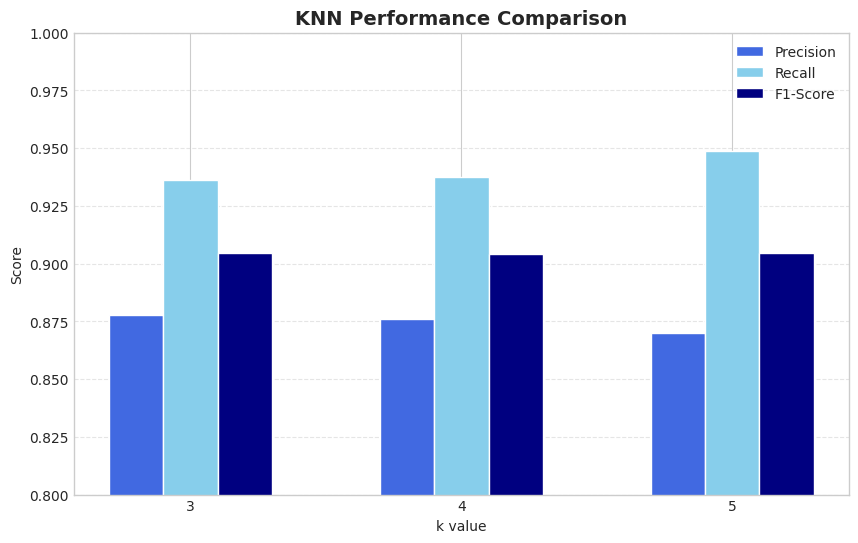

In [51]:
# Keep only macro avg rows
macro_df = final_report.loc['macro avg'].copy()

# Reset index for cleaner plotting
macro_df = macro_df.reset_index(drop=True)

plt.figure(figsize=(10,6))

x = np.arange(len(best_ks))
width = 0.2

# Bars
plt.bar(x - width, macro_df['precision'], width, label='Precision', color='royalblue')
plt.bar(x, macro_df['recall'], width, label='Recall', color='skyblue')
plt.bar(x + width, macro_df['f1-score'], width, label='F1-Score', color='navy')

# Labels
plt.xlabel('k value')
plt.ylabel('Score')
plt.title('KNN Performance Comparison')

plt.xticks(x, best_ks)

plt.ylim(0.8, 1.0)

plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [52]:
# plt.figure(figsize=(6,4))

# bars = plt.bar(best_ks, accuracies, color='darkblue')

# plt.xlabel("k value")
# plt.ylabel("Accuracy")
# plt.title("KNN Accuracy Comparison")

# plt.xticks(best_ks)

# plt.grid(True)
# for bar in bars:
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width()/2,
#         height,
#         f'{height:.3f}',
#         ha='center',
#         va='bottom'
#     )


plt.show()

DECISION TREE

In [53]:
from sklearn.tree import DecisionTreeClassifier
from itertools import product

In [54]:
max_depths = [3, 4, 5]
min_samples_leafs = [1, 5, 10]
criterions = ["gini", "entropy"]

results = []

for depth, leaf, crit in product(max_depths, min_samples_leafs, criterions):
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=leaf,
        criterion=crit,
        random_state=42
    )

    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "max_depth": depth,
        "min_samples_leaf": leaf,
        "criterion": crit,
        "accuracy": acc,
        "model" : model
    })

# Sort results
results = sorted(results, key=lambda x: x["accuracy"], reverse=True)

df = pd.DataFrame(results)

print(df.head())

   max_depth  min_samples_leaf criterion  accuracy  \
0          4                 1   entropy      0.56   
1          4                 5   entropy      0.56   
2          4                10   entropy      0.56   
3          5                10   entropy      0.56   
4          3                 1   entropy      0.55   

                                               model  
0  DecisionTreeClassifier(criterion='entropy', ma...  
1  DecisionTreeClassifier(criterion='entropy', ma...  
2  DecisionTreeClassifier(criterion='entropy', ma...  
3  DecisionTreeClassifier(criterion='entropy', ma...  
4  DecisionTreeClassifier(criterion='entropy', ma...  


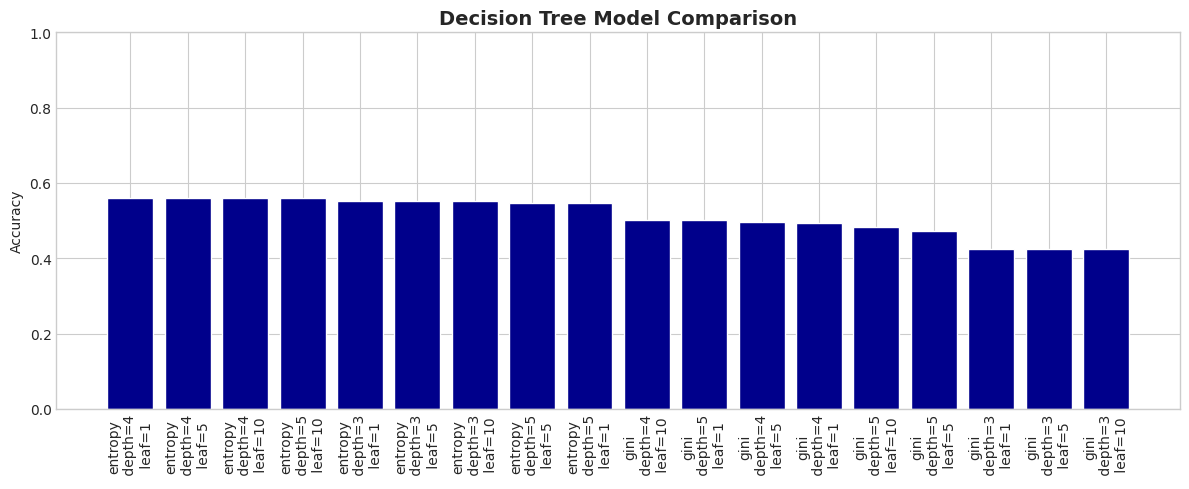

In [55]:
plt.figure(figsize=(12, 5))

labels = (
    df["criterion"].astype(str)
    + "\n depth=" + df["max_depth"].astype(str)
    + "\n leaf=" + df["min_samples_leaf"].astype(str)
)

plt.bar(range(len(df)), df["accuracy"], color='darkBlue')
plt.xticks(range(len(df)), labels, rotation=90)
plt.ylim(0, 1)
plt.title("Decision Tree Model Comparison")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [56]:
best_model = df.iloc[0]["model"]
print("Best accuracy:", df.iloc[0]["accuracy"])
print("Best params:")
print(df.iloc[0][["max_depth", "min_samples_leaf", "criterion"]])

Best accuracy: 0.5611210494931426
Best params:
max_depth                 4
min_samples_leaf          1
criterion           entropy
Name: 0, dtype: object


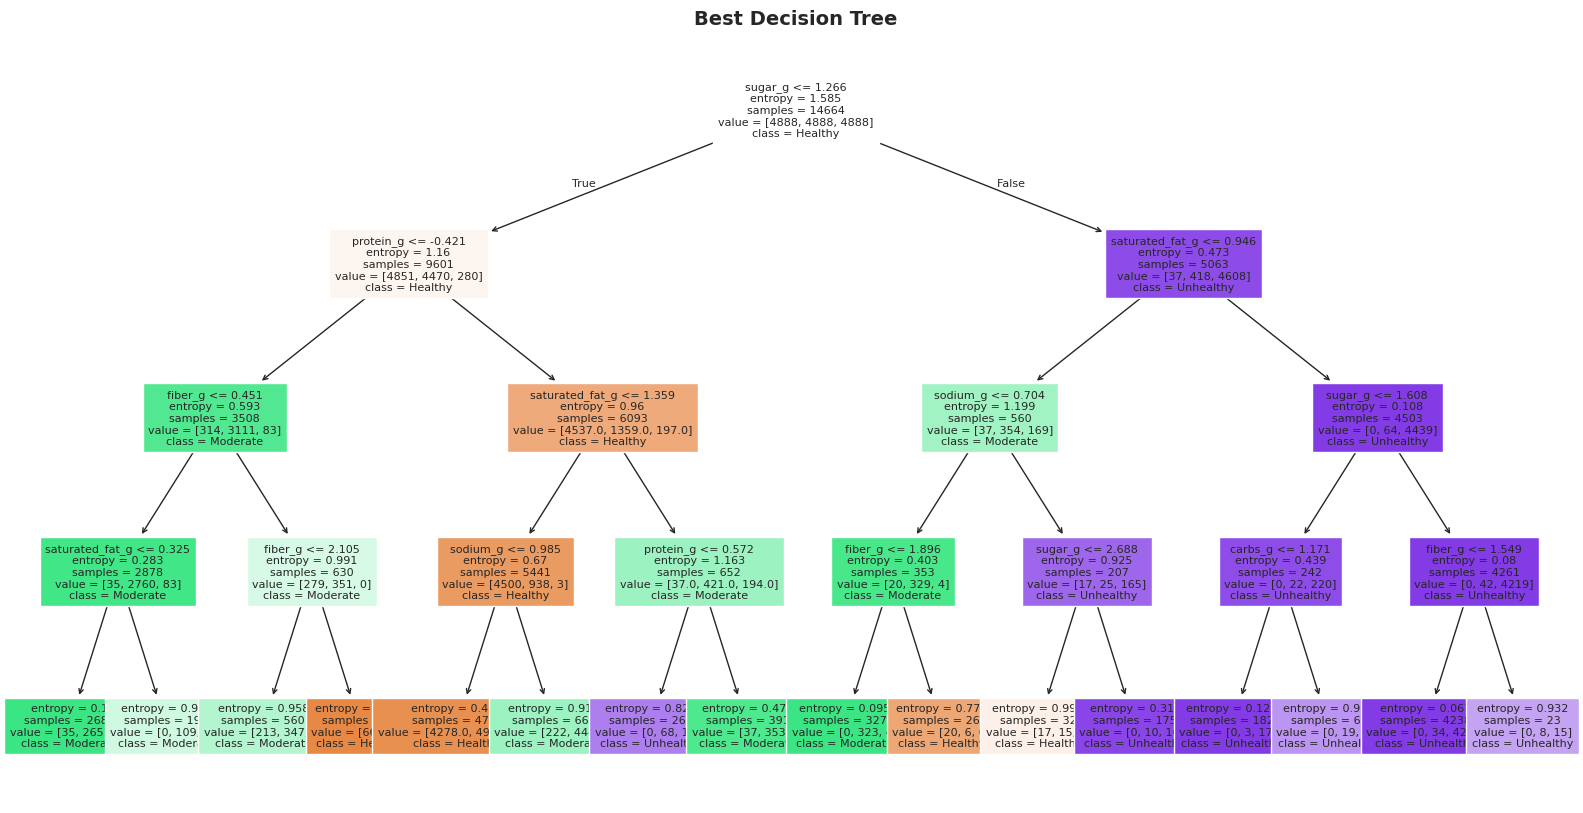

In [57]:
plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=best_model.classes_,
    filled=True,
    fontsize=8
)


plt.title("Best Decision Tree")
plt.show()

In [58]:
dtree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42,
    criterion='entropy'
)

dtree.fit(X_train_resampled, y_train_resampled)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [59]:
y_pred_tree = dtree.predict(X_test)

In [60]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

acc_tree = accuracy_score(y_test, y_pred_tree)
print("Accuracy:", acc_tree)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.5611210494931426

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.40      0.61      0.48       397
    Moderate       0.85      0.53      0.65      1222
   Unhealthy       0.17      0.90      0.28        58

    accuracy                           0.56      1677
   macro avg       0.47      0.68      0.47      1677
weighted avg       0.72      0.56      0.60      1677



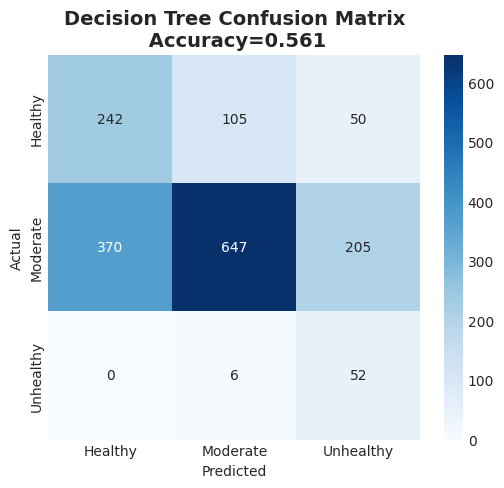

In [61]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,5))
acc_tree = accuracy_score(y_test, y_pred_tree)
sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=dtree.classes_,
    yticklabels=dtree.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Decision Tree Confusion Matrix\n Accuracy={acc_tree:.3f}")

plt.show()

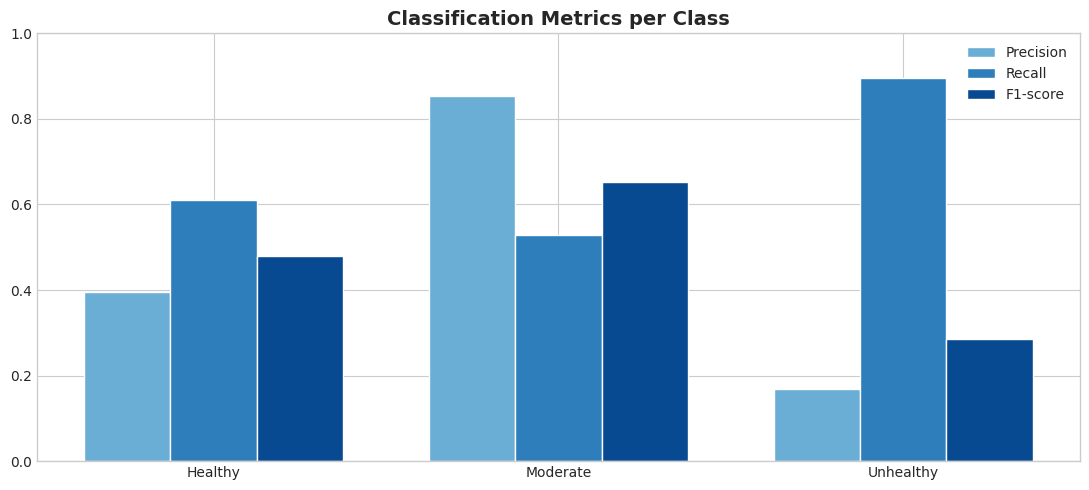

In [62]:
report = classification_report(y_test, y_pred_tree, output_dict=True)

classes = [k for k in report.keys() if k not in ("accuracy", "macro avg", "weighted avg")]

precision = [report[c]["precision"] for c in classes]
recall = [report[c]["recall"] for c in classes]
f1 = [report[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(11, 5))

# Blue shades from colormap
colors = plt.cm.Blues([0.5, 0.7, 0.9])

plt.bar(x - width, precision, width=width, label="Precision", color=colors[0])
plt.bar(x, recall, width=width, label="Recall", color=colors[1])
plt.bar(x + width, f1, width=width, label="F1-score", color=colors[2])

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.title("Classification Metrics per Class")
plt.legend()
plt.tight_layout()
plt.show()

Feature importance

In [63]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

           Feature  Importance
3          sugar_g        0.54
0        protein_g        0.19
1  saturated_fat_g        0.17
5         sodium_g        0.06
4          fiber_g        0.05
2          carbs_g        0.00


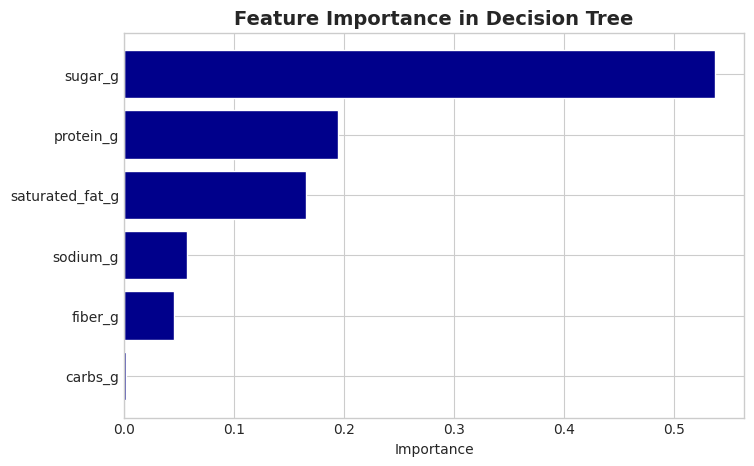

In [64]:
plt.figure(figsize=(8,5))

plt.barh(
    importance['Feature'],
    importance['Importance'],
    color='darkBlue'
)

plt.xlabel("Importance")
plt.title("Feature Importance in Decision Tree")

plt.gca().invert_yaxis()

plt.show()

Naive Bayes

In [65]:
from sklearn.naive_bayes import GaussianNB

In [66]:
nb_model = GaussianNB()
nb_model.fit(X_train_resampled, y_train_resampled)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [67]:
y_pred_nb = nb_model.predict(X_test_scaled)

In [68]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
acc_bayes =  accuracy_score(y_test, y_pred_nb)
print("Accuracy:",acc_bayes)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.8670244484197973

Classification Report:

              precision    recall  f1-score   support

     Healthy       0.74      0.95      0.83       397
    Moderate       0.97      0.84      0.90      1222
   Unhealthy       0.43      0.86      0.58        58

    accuracy                           0.87      1677
   macro avg       0.72      0.88      0.77      1677
weighted avg       0.90      0.87      0.87      1677



              precision    recall  f1-score   support

     Healthy       0.74      0.95      0.83       397
    Moderate       0.97      0.84      0.90      1222
   Unhealthy       0.43      0.86      0.58        58

    accuracy                           0.87      1677
   macro avg       0.72      0.88      0.77      1677
weighted avg       0.90      0.87      0.87      1677



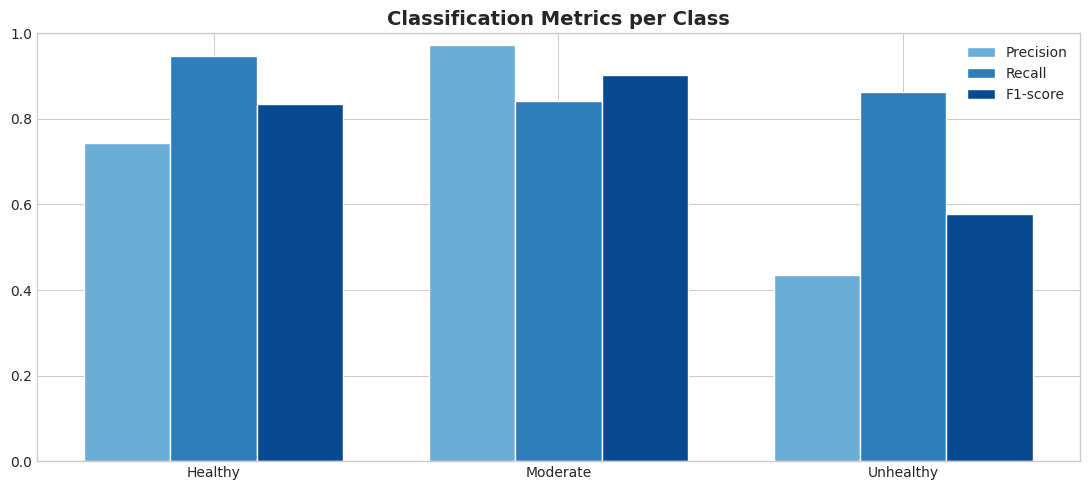

In [69]:
print(classification_report(y_test, y_pred_nb))

report_nb = classification_report(y_test, y_pred_nb, output_dict=True)

classes = [k for k in report_nb.keys() if k not in ("accuracy", "macro avg", "weighted avg")]

precision = [report_nb[c]["precision"] for c in classes]
recall = [report_nb[c]["recall"] for c in classes]
f1 = [report_nb[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(11, 5))

# Blue shades from colormap
colors = plt.cm.Blues([0.5, 0.7, 0.9])

plt.bar(x - width, precision, width=width, label="Precision", color=colors[0])
plt.bar(x, recall, width=width, label="Recall", color=colors[1])
plt.bar(x + width, f1, width=width, label="F1-score", color=colors[2])

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.title("Classification Metrics per Class")
plt.legend()
plt.tight_layout()
plt.show()

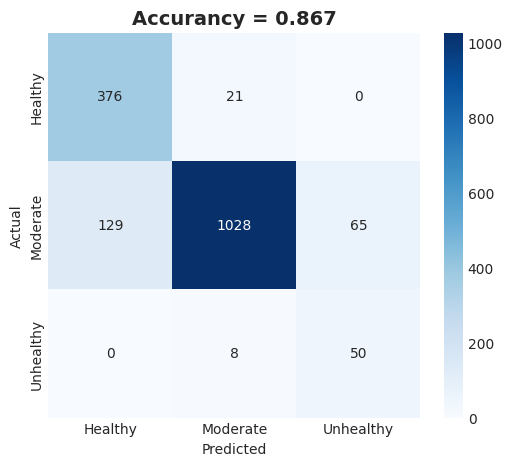

In [70]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Accurancy = {acc_bayes:.3f}")

plt.show()

SVM


In [71]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score


In [72]:


pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(
    X_train_resampled
)

X_test_pca = pca.transform(
    X_test_scaled
)

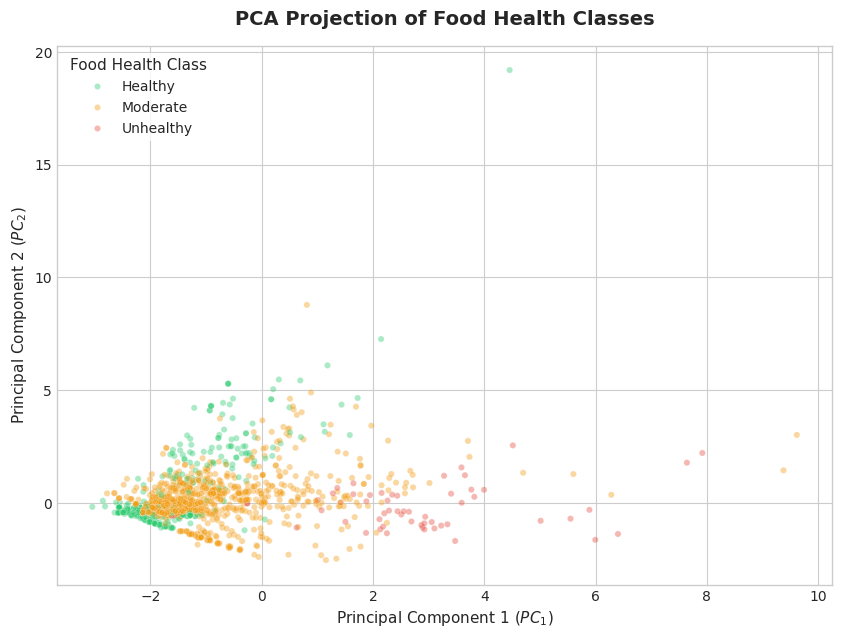

In [73]:

fig, ax = plt.subplots(
    figsize=(10,7)
)


plot_df = pd.DataFrame({
    "PC1": X_test_pca[:,0],
    "PC2": X_test_pca[:,1],
    "Class": y_test
})

custom_palette = {
    'Healthy': '#2ecc71',    # Vibrant, fresh green
    'Moderate': '#f39c12',   # Clear amber/orange
    'Unhealthy': '#e74c3c'  # Noticeable crimson red
}

# fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Class',
    hue_order=['Healthy', 'Moderate', 'Unhealthy'], # Forces consistent layering & legend order
    palette=custom_palette,
    alpha=0.4,          # Semi-transparency to reveal overlapping densities
    s=20,               # Smaller marker size reduces cluttering
    edgecolor='w',      # Fine white borders give distinct definition to nested dots
    linewidth=0.3,
    ax=ax
)

ax.set_title('PCA Projection of Food Health Classes', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Principal Component 1 ($PC_1$)', fontsize=11)
ax.set_ylabel('Principal Component 2 ($PC_2$)', fontsize=11)

ax.legend(
    title='Food Health Class', 
    title_fontsize='11', 
    loc='upper left', 
    frameon=True, 
    facecolor='white', 
    edgecolor='none'
)

# Display the polished visualization
plt.show()

In [74]:
C_values = [0.01, 0.1, 1, 10, 100]

f1_scores = []

for C in C_values:

    svm = SVC(
        kernel='rbf',
        C=C,
        gamma='scale',
        class_weight='balanced',
        random_state=42
    )

    svm.fit(X_train_resampled, y_train_resampled)

    preds = svm.predict(X_test_scaled)

    score = f1_score(
        y_test,
        preds,
        average='macro'
    )

    f1_scores.append(score)

    print(f"C={C}  Macro F1={score:.4f}")

C=0.01  Macro F1=0.8041
C=0.1  Macro F1=0.8156
C=1  Macro F1=0.8539
C=10  Macro F1=0.8921
C=100  Macro F1=0.8738


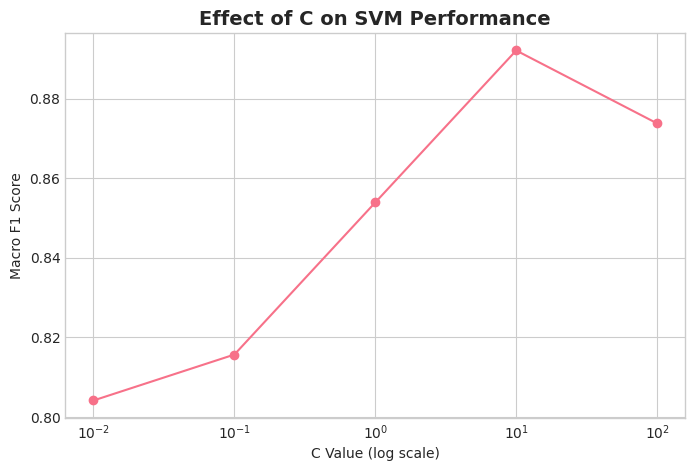

In [75]:
plt.figure(figsize=(8,5))

plt.plot(
    C_values,
    f1_scores,
    marker='o'
)

plt.xscale('log')

plt.xlabel('C Value (log scale)')
plt.ylabel('Macro F1 Score')
plt.title('Effect of C on SVM Performance')

plt.grid(True)

plt.show()

In [76]:
best_C = C_values[np.argmax(f1_scores)]

print("Best C:", best_C)

Best C: 10


In [77]:
best_svm = SVC(
    kernel='rbf',
    C=best_C,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

best_svm.fit(
    X_train_resampled,
    y_train_resampled
)

y_pred_svm = best_svm.predict(
    X_test_scaled
)

In [78]:


print(classification_report(
    y_test,
    y_pred_svm
))

              precision    recall  f1-score   support

     Healthy       0.87      0.93      0.90       397
    Moderate       0.97      0.94      0.96      1222
   Unhealthy       0.80      0.84      0.82        58

    accuracy                           0.94      1677
   macro avg       0.88      0.91      0.89      1677
weighted avg       0.94      0.94      0.94      1677



In [79]:
svm_vis = SVC(
    kernel='rbf',
    C=best_C,
    gamma='scale',
    class_weight='balanced'
)

svm_vis.fit(
    X_train_pca,
    y_train_resampled
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


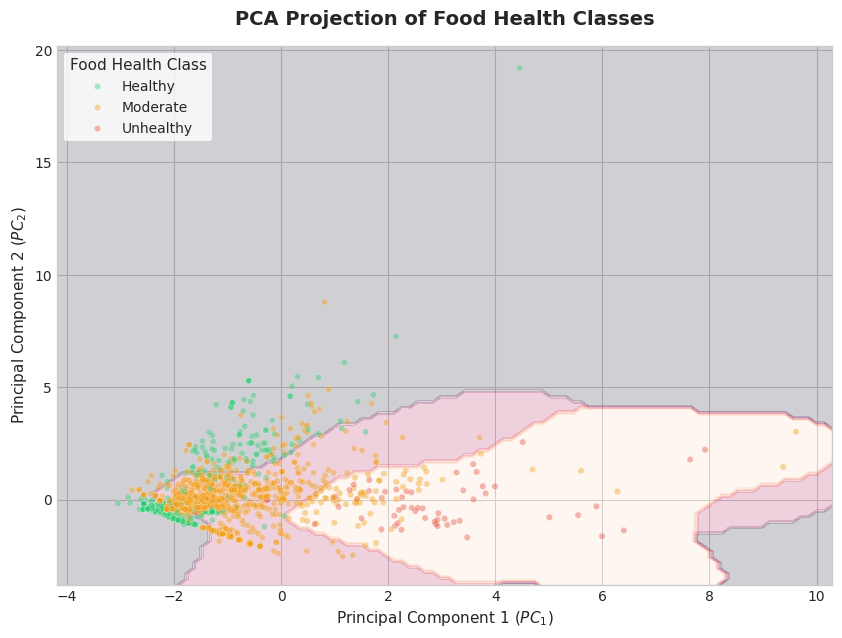

In [80]:
from sklearn.inspection import DecisionBoundaryDisplay


fig, ax = plt.subplots(
    figsize=(10,7)
)

DecisionBoundaryDisplay.from_estimator(
    svm_vis,
    X_train_pca,
    response_method="predict",
    alpha=0.2,
    ax=ax
)

plot_df = pd.DataFrame({
    "PC1": X_test_pca[:,0],
    "PC2": X_test_pca[:,1],
    "Class": y_test
})

custom_palette = {
    'Healthy': '#2ecc71',    # Vibrant, fresh green
    'Moderate': '#f39c12',   # Clear amber/orange
    'Unhealthy': '#e74c3c'  # Noticeable crimson red
}

# fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Class',
    hue_order=['Healthy', 'Moderate', 'Unhealthy'], # Forces consistent layering & legend order
    palette=custom_palette,
    alpha=0.4,          # Semi-transparency to reveal overlapping densities
    s=20,               # Smaller marker size reduces cluttering
    edgecolor='w',      # Fine white borders give distinct definition to nested dots
    linewidth=0.3,
    ax=ax
)

ax.set_title('PCA Projection of Food Health Classes', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Principal Component 1 ($PC_1$)', fontsize=11)
ax.set_ylabel('Principal Component 2 ($PC_2$)', fontsize=11)

ax.legend(
    title='Food Health Class', 
    title_fontsize='11', 
    loc='upper left', 
    frameon=True, 
    facecolor='white', 
    edgecolor='none'
)

# Display the polished visualization
plt.show()

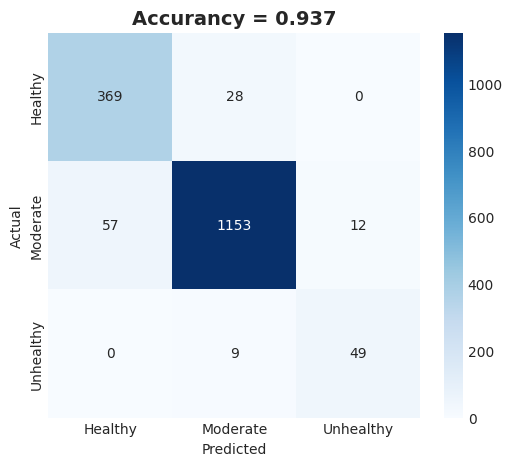

In [81]:
cm_nb = confusion_matrix(y_test, y_pred_svm)
acc_svm =  accuracy_score(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nb_model.classes_,
    yticklabels=nb_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Accurancy = {acc_svm:.3f}")

plt.show()

              precision    recall  f1-score   support

     Healthy       0.87      0.93      0.90       397
    Moderate       0.97      0.94      0.96      1222
   Unhealthy       0.80      0.84      0.82        58

    accuracy                           0.94      1677
   macro avg       0.88      0.91      0.89      1677
weighted avg       0.94      0.94      0.94      1677



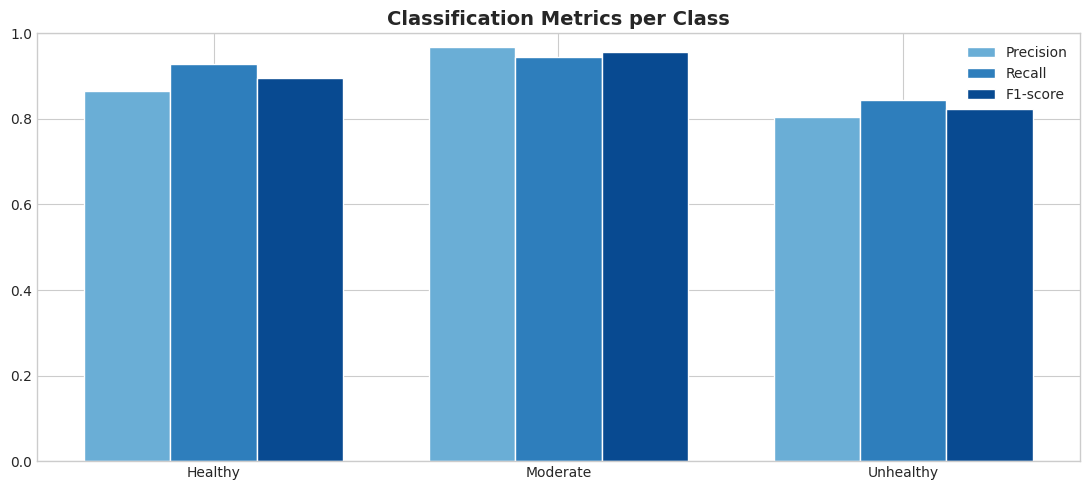

In [82]:
print(classification_report(y_test, y_pred_svm))

report_svm = classification_report(y_test, y_pred_svm, output_dict=True)

classes = [k for k in report_svm.keys() if k not in ("accuracy", "macro avg", "weighted avg")]

precision = [report_svm[c]["precision"] for c in classes]
recall = [report_svm[c]["recall"] for c in classes]
f1 = [report_svm[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(11, 5))

# Blue shades from colormap
colors = plt.cm.Blues([0.5, 0.7, 0.9])

plt.bar(x - width, precision, width=width, label="Precision", color=colors[0])
plt.bar(x, recall, width=width, label="Recall", color=colors[1])
plt.bar(x + width, f1, width=width, label="F1-score", color=colors[2])

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.title("Classification Metrics per Class")
plt.legend()
plt.tight_layout()
plt.show()

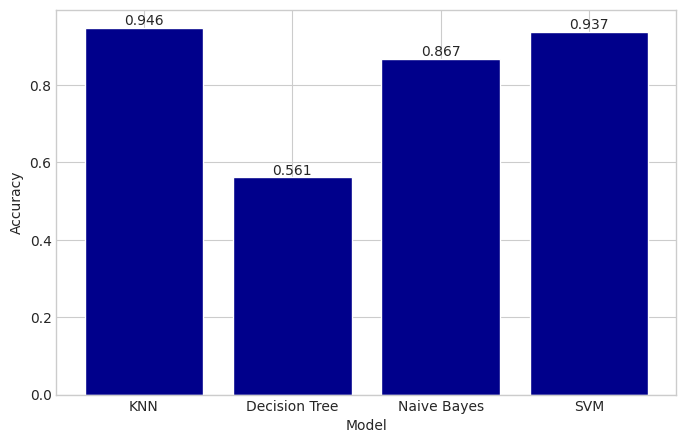

In [83]:
acc_results = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Naive Bayes', 'SVM'],
    'Accuracy': [acc_knn, acc_tree, acc_bayes, acc_svm]
})

plt.figure(figsize=(8,5))

bars = plt.bar(
    acc_results['Model'],
    acc_results['Accuracy'],
    color='darkBlue'
)

plt.ylabel('Accuracy')
plt.xlabel('Model')
# plt.title('Model Accuracy Comparison')


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom'
    )

# plt.ylim(0.8, 1.0)

plt.show()